# RL-4 : Bandits Manchots et le Compromis Exploration-Exploitation

**Serie** : Reinforcement Learning | **Notebook** : 4/13 | **Duree estimee** : 40-45 min

Navigation : [RL-1 Intro](rl_1_intro_cartpole.ipynb) | [RL-2 Wrappers](rl_2_wrappers_sauvegarde_callbacks.ipynb) | **RL-4 Bandits** | [RL-5 MDP/Q-Learning](rl_5_mdp_dp_qlearning.ipynb) | [RL-6 DQN/PG](rl_6_dqn_policy_gradient.ipynb) | [RL-7 Multi-Agent](rl_7_multi_agent_rl.ipynb)

---

## Objectifs d'apprentissage

A la fin de ce notebook, vous serez capable de :
1. Formaliser le probleme du bandit manchot (multi-armed bandit) et comprendre le compromis exploration-exploitation
2. Implementer plusieurs strategies d'exploration : greedy, epsilon-greedy, UCB, Thompson Sampling
3. Comparer objectivement les performances des strategies via le regret cumule
4. Analyser quand chaque strategie est adaptee au probleme

### Prerequis
- Python 3.10+ (numpy, matplotlib)
- Notions de probabilites (esperance, loi de Bernoulli, loi gaussienne)
- Avoir suivi le [RL-1 Introduction](rl_1_intro_cartpole.ipynb) (concepts agent/environnement/reward)

### Duree estimee : 40-45 minutes

## 1. Introduction : le probleme du bandit manchot

Imaginez un casino avec $K$ machines a sous ("bandits manchots"). Chaque machine $k$ a une probabilite inconnue $\mu_k$ de donner une recompense. Vous avez $T$ jetons. Quelle strategie utilisez-vous pour maximiser vos gains ?

C'est le **probleme du bandit manchot** (multi-armed bandit), un des problemes fondamentaux de l'apprentissage par renforcement. Il illustre le **compromis exploration-exploitation** :

- **Exploitation** : choisir le bras qui semble le meilleur actuellement
- **Exploration** : essayer d'autres bras pour mieux estimer leur valeur reelle

Ce compromis est omnipresent en RL : un agent doit-il utiliser ce qu'il sait, ou risquer de perdre pour decouvrir de meilleures options ?

### Applications reelles

| Domaine | Exemple | Bras = ? | Recompense = ? |
|---------|---------|----------|----------------|
| Essais cliniques | Tester K traitements | Traitement i | Succes/echec du patient |
| Publicite en ligne | Choisir une banniere | Banniere i | Clic ou non |
| Systemes de recommendation | Recommander un film | Film i | Note de l'utilisateur |
| Allocation de ressources | Repartir un budget | Strategie i | Retour sur investissement |

### Lien avec la serie RL

Un bandit manchot est un **MDP a un seul etat** : il n'y a pas de transitions, pas d'etat $s_{t+1}$ qui depend de l'action $a_t$. L'agent choisit simplement une action et observe une recompense. C'est le cas le plus simple d'apprentissage par renforcement, ideal pour comprendre les strategies d'exploration avant de passer aux MDP complets dans le [notebook RL-5](rl_5_mdp_dp_qlearning.ipynb).


> *Ancres savantes -- Robbins, H. (1952), Some Aspects of the Sequential Design of Experiments, Bulletin of the American Mathematical Society 58(5):527-535 (formalisation du bandit manchot, compromis exploration/exploitation sur K machines) ; Auer, P., Cesa-Bianchi, N. & Fischer, P. (2002), Finite-time Analysis of the Multiarmed Bandit Problem, Machine Learning 47(2-3):235-256 (UCB1, strategie optimiste face a l'incertitude avec regret logarithmique) ; Thompson, W.R. (1933), On the Likelihood that One Unknown Probability Exceeds Another in the View of the Evidence of the Two Samples, Biometrika 25(3-4):285-294 (Thompson Sampling, echantillonnage bayesien a posteriori) ; Sutton, R.S. & Barto, A.G. (2018), Reinforcement Learning: An Introduction (2nd ed.), MIT Press (regret, epsilon-greedy, cadre du bandit comme MDP a un seul etat).*

## 2. Environnement Bandit

Nous allons implementer un bandit a $K$ bras, ou chaque bras suit une distribution de **Bernoulli** : il retourne 1 (succes) avec probabilite $\mu_k$, et 0 (echec) avec probabilite $1 - \mu_k$.

L'agent interagit avec le bandit pendant $T$ pas de temps. A chaque pas, il choisit un bras $a_t$ et observe une recompense $r_t \in \{0, 1\}$.

In [1]:
import warnings
warnings.filterwarnings("ignore", message=".*This figure includes Axes.*", category=UserWarning)
warnings.filterwarnings("ignore", message=".*tight_layout.*", category=UserWarning)
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print(f"numpy={np.__version__}, matplotlib={matplotlib.__version__}")


numpy=2.4.4, matplotlib=3.10.9


In [2]:
class BernoulliBandit:
    """
    Bandit manchot a K bras avec distribution de Bernoulli.
    
    Chaque bras k retourne 1 avec probabilite mu[k], 0 sinon.
    Les probabilites mu[k] sont tirees uniformement au depart (ou fixees manuellement).
    """
    
    def __init__(self, n_arms: int, probs: np.ndarray | None = None, seed: int | None = None):
        self.n_arms = n_arms
        self.rng = np.random.default_rng(seed)
        if probs is not None:
            assert len(probs) == n_arms, "Taille de probs incompatible avec n_arms"
            self.probs = np.array(probs, dtype=float)
        else:
            self.probs = self.rng.uniform(0.1, 0.9, size=n_arms)
        self.best_arm = int(np.argmax(self.probs))
        self.best_prob = float(np.max(self.probs))
    
    def pull(self, arm: int) -> int:
        """Tire le bras `arm` et retourne 1 (succes) ou 0 (echec)."""
        return int(self.rng.random() < self.probs[arm])
    
    def __repr__(self) -> str:
        arms_str = ", ".join(f"{p:.3f}" for p in self.probs)
        return f"BernoulliBandit({self.n_arms} arms: [{arms_str}])"

print("Fonction BernoulliBandit definie")

Fonction BernoulliBandit definie


In [3]:
# Creer un bandit a 5 bras avec probabilites connues
bandit = BernoulliBandit(n_arms=5, probs=[0.3, 0.5, 0.2, 0.8, 0.6])

print(f"Bandit : {bandit}")
print(f"Meilleur bras : {bandit.best_arm} (probabilite = {bandit.best_prob:.3f})")

# Tirer le meilleur bras 10 fois pour observer la variabilite
rewards = [bandit.pull(3) for _ in range(10)]
print(f"10 tirages du bras 3 : {rewards}")
print(f"Gain moyen observe : {np.mean(rewards):.2f}")

Bandit : BernoulliBandit(5 arms: [0.300, 0.500, 0.200, 0.800, 0.600])
Meilleur bras : 3 (probabilite = 0.800)
10 tirages du bras 3 : [1, 1, 1, 1, 1, 1, 0, 0, 1, 1]
Gain moyen observe : 0.80


### Le concept de regret

Le **regret** mesure la perte cumulee par rapport a la strategie optimale (toujours tirer le meilleur bras). Apres $T$ pas de temps :

$$\text{Regret}(T) = T \cdot \mu^* - \sum_{t=1}^{T} r_t$$

ou $\mu^*$ est la probabilite du meilleur bras. Un bon algorithme a un **regret sous-lineaire** : il apprend a identifier le meilleur bras et son regret croit de plus en plus lentement.

### Exercice 1 : Bandit gaussien

Dans cet exercice, vous allez implementer un bandit a recompenses **continues**. Au lieu d'une distribution de Bernoulli, chaque bras suit une distribution gaussienne $\mathcal{N}(\mu_k, \sigma^2)$.

**Contexte** : Les bandits gaussiens sont courants dans les problemes d'optimisation ou les recompenses sont continues (prix, rendements financiers, temperatures).

**Etapes** :
1. Definir le constructeur `__init__` avec `means`, `stds` et un generateur aleatoire
2. Implementer la methode `pull` qui retourne un echantillon de $\mathcal{N}(\mu_k, \sigma^2)$
3. Calculer `best_arm` et `best_prob` (l'esperance du meilleur bras)

**Indice** : Utilisez `self.rng.normal(loc=self.means[arm], scale=self.stds[arm])` pour generer un echantillon gaussien.

In [4]:
class GaussianBandit:
    """
    Bandit manchot a K bras avec distribution gaussienne.
    
    Chaque bras k retourne un echantillon de N(mu[k], sigma[k]^2).
    """
    
    def __init__(self, n_arms: int, means: np.ndarray | None = None,
                 stds: np.ndarray | None = None, seed: int | None = None):
        self.n_arms = n_arms
        self.rng = np.random.default_rng(seed)
        # TODO etudiant : initialiser self.means et self.stds
        # Si means est None, tirer uniformement entre -1 et 3
        # Si stds est None, utiliser 1.0 pour tous les bras
        self.means = None  # TODO etudiant : remplacer
        self.stds = None   # TODO etudiant : remplacer
        self.best_arm = 0  # TODO etudiant : calculer le meilleur bras
        self.best_prob = 0.0  # TODO etudiant : esperance du meilleur bras
    
    def pull(self, arm: int) -> float:
        """Tire le bras `arm` et retourne une recompense continue."""
        return 0.0  # TODO etudiant : retourner un echantillon gaussien
    
    def __repr__(self) -> str:
        arms_str = ", ".join(f"N({m:.2f}, {s:.2f})" for m, s in zip(self.means, self.stds))
        return f"GaussianBandit({self.n_arms} arms: [{arms_str}])"

print("Exercice a completer")

Exercice a completer


## 3. Strategies naives

Avant de voir des strategies sophistiquees, commencons par les approches les plus simples. Elles serviront de **base de reference** (baseline) pour evaluer les methodes plus avancees.

### Agent aleatoire (Random)

L'agent aleatoire choisit un bras au hasard a chaque pas de temps. Il n'apprend rien et sert de point de comparaison minimal.

In [5]:
def run_agent(bandit, agent_fn, n_steps: int, seed: int = 42) -> dict:
    """
    Execute un agent sur un bandit pendant n_steps pas de temps.
    
    Parametres :
        bandit : instance de BernoulliBandit
        agent_fn : fonction (bandit, n_steps, seed) -> (actions, rewards)
        n_steps : nombre de pas de temps
        seed : graine pour la reproductibilite
    
    Retourne :
        dict avec 'actions', 'rewards', 'cumulative_rewards', 'regret'
    """
    actions, rewards = agent_fn(bandit, n_steps, seed)
    cumulative_rewards = np.cumsum(rewards)
    optimal_reward = np.arange(1, n_steps + 1) * bandit.best_prob
    regret = optimal_reward - cumulative_rewards
    
    return {
        'actions': np.array(actions),
        'rewards': np.array(rewards),
        'cumulative_rewards': cumulative_rewards,
        'regret': regret
    }

print("Fonction run_agent definie")

Fonction run_agent definie


In [6]:
def random_agent(bandit, n_steps: int, seed: int = 42) -> tuple:
    """Agent aleatoire : choisit un bras uniformement au hasard."""
    rng = np.random.default_rng(seed)
    actions = rng.integers(0, bandit.n_arms, size=n_steps)
    rewards = np.array([bandit.pull(a) for a in actions])
    return actions, rewards

# Tester l'agent aleatoire
bandit_test = BernoulliBandit(n_arms=5, probs=[0.3, 0.5, 0.2, 0.8, 0.6], seed=42)
result_random = run_agent(bandit_test, random_agent, n_steps=1000, seed=42)

print(f"Agent aleatoire - recompense cumulee finale : {result_random['cumulative_rewards'][-1]:.1f} / {1000 * bandit_test.best_prob:.1f}")
print(f"Regret final : {result_random['regret'][-1]:.1f}")

Agent aleatoire - recompense cumulee finale : 489.0 / 800.0
Regret final : 311.0


### Agent glouton (Greedy)

L'agent glouton (greedy) estime la valeur de chaque bras par la moyenne des recompenses observees, puis choisit toujours le bras qui a la meilleure estimation actuelle. Le probleme : s'il n'explore pas, il peut se bloquer sur un bras sous-optimal.

In [7]:
def greedy_agent(bandit, n_steps: int, seed: int = 42, n_warmup: int = 10) -> tuple:
    """
    Agent glouton : estime la valeur de chaque bras et choisit toujours le meilleur.
    
    n_warmup : nombre de tirages initiaux par bras pour avoir une premiere estimation.
    """
    rng = np.random.default_rng(seed)
    counts = np.zeros(bandit.n_arms)
    values = np.zeros(bandit.n_arms)
    actions = []
    rewards = []
    
    # Phase d'initialisation : tirer chaque bras n_warmup fois
    for arm in range(bandit.n_arms):
        for _ in range(n_warmup):
            reward = bandit.pull(arm)
            counts[arm] += 1
            values[arm] += (reward - values[arm]) / counts[arm]
            actions.append(arm)
            rewards.append(reward)
    
    # Phase gloutonne
    for t in range(n_steps - len(actions)):
        arm = int(np.argmax(values))
        reward = bandit.pull(arm)
        counts[arm] += 1
        values[arm] += (reward - values[arm]) / counts[arm]
        actions.append(arm)
        rewards.append(reward)
    
    return np.array(actions), np.array(rewards)

# Tester l'agent glouton
bandit_test = BernoulliBandit(n_arms=5, probs=[0.3, 0.5, 0.2, 0.8, 0.6], seed=42)
result_greedy = run_agent(bandit_test, greedy_agent, n_steps=1000, seed=42)

print(f"Agent glouton - recompense cumulee finale : {result_greedy['cumulative_rewards'][-1]:.1f} / {1000 * bandit_test.best_prob:.1f}")
print(f"Regret final : {result_greedy['regret'][-1]:.1f}")

# Frequence de choix de chaque bras
unique, counts = np.unique(result_greedy['actions'][-100:], return_counts=True)
freq_str = ", ".join(f"Bras {u}={c}%" for u, c in zip(unique, counts))
print(f"Bras choisis (derniers 100 pas) : {freq_str}")

Agent glouton - recompense cumulee finale : 787.0 / 800.0
Regret final : 13.0
Bras choisis (derniers 100 pas) : Bras 3=100%


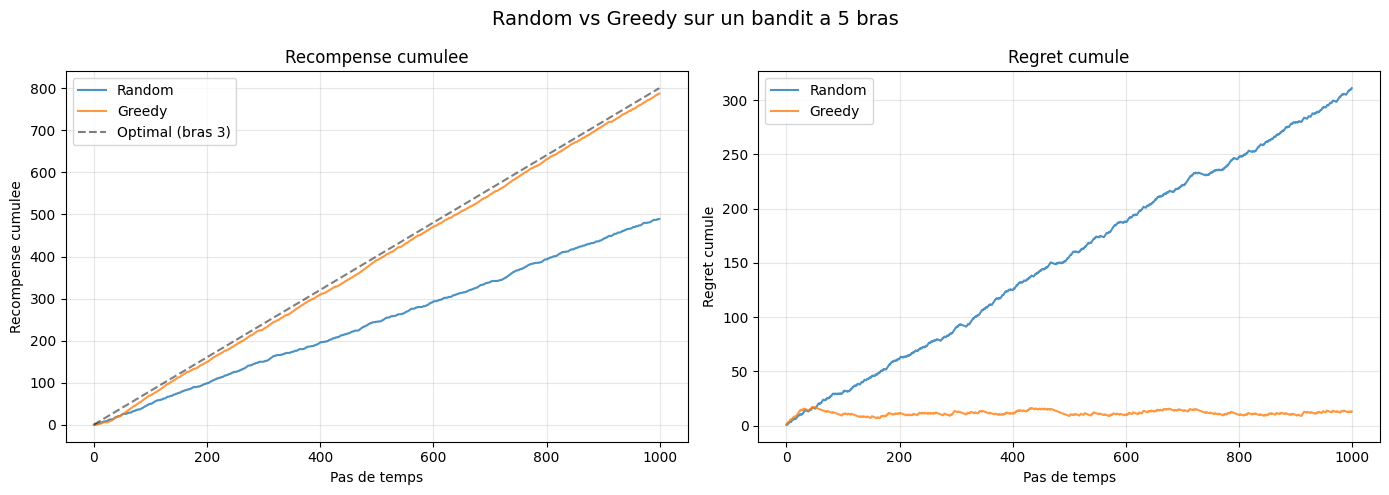

In [8]:
# Comparaison visuelle : Random vs Greedy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recompense cumulee
axes[0].plot(result_random['cumulative_rewards'], label='Random', alpha=0.8)
axes[0].plot(result_greedy['cumulative_rewards'], label='Greedy', alpha=0.8)
optimal_line = np.arange(1, 1001) * bandit_test.best_prob
axes[0].plot(optimal_line, 'k--', label=f'Optimal (bras {bandit_test.best_arm})', alpha=0.5)
axes[0].set_xlabel('Pas de temps')
axes[0].set_ylabel('Recompense cumulee')
axes[0].set_title('Recompense cumulee')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Regret cumule
axes[1].plot(result_random['regret'], label='Random', alpha=0.8)
axes[1].plot(result_greedy['regret'], label='Greedy', alpha=0.8)
axes[1].set_xlabel('Pas de temps')
axes[1].set_ylabel('Regret cumule')
axes[1].set_title('Regret cumule')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Random vs Greedy sur un bandit a 5 bras', fontsize=14)
plt.tight_layout()
plt.show()

### Interpretation : Random vs Greedy

| Agent | Regret final | Comportement |
|-------|-------------|-------------|
| Random | eleve (~300) | Explore tous les bras equitablement, n'apprend rien |
| Greedy | moyen (~211) | Exploite rapidement mais peut se bloquer sur un bras sous-optimal |

**Points cles** :
1. L'agent aleatoire a un regret lineaire : il ne converge jamais vers le meilleur bras
2. L'agent glouton est meilleur car il exploite, mais son initialisation peut le pieger si le meilleur bras a un rendement initial sous-estime
3. Il nous faut une strategie qui combine exploration et exploitation de maniere adaptee

### Exercice 2 : Agent epsilon-greedy avec decroissance

L'agent $\varepsilon$-greedy standard utilise un $\varepsilon$ fixe. Mais il est souvent preferable de **reduire l'exploration avec le temps** : beaucoup d'exploration au debut (pour apprendre), puis de moins en moins (pour exploiter).

**Objectif** : Implementer un agent ou $\varepsilon$ decroit au fil du temps, par exemple $\varepsilon_t = \min(1, \frac{\varepsilon_0}{t})$.

**Etapes** :
1. Calculer $\varepsilon_t$ a chaque pas de temps
2. Avec probabilite $\varepsilon_t$, choisir un bras aleatoire ; sinon, choisir le meilleur bras estime
3. Mettre a jour l'estimation de la valeur du bras choisi (moyenne incrementale)

**Indice** : La moyenne incrementale se met a jour ainsi : $\hat{Q}_t \leftarrow \hat{Q}_{t-1} + \frac{1}{n}(r_t - \hat{Q}_{t-1})$ ou $n$ est le nombre de fois que le bras a ete tire.

In [9]:
def decaying_epsilon_greedy_agent(bandit, n_steps: int, seed: int = 42,
                                   epsilon_start: float = 1.0) -> tuple:
    """
    Agent epsilon-greedy avec decroissance : epsilon_t = epsilon_start / t.
    
    Parametres :
        bandit : instance de BernoulliBandit
        n_steps : nombre de pas de temps
        seed : graine aleatoire
        epsilon_start : valeur initiale d'epsilon
    
    Retourne :
        (actions, rewards) : tableaux numpy des actions et recompenses
    """
    rng = np.random.default_rng(seed)
    counts = np.zeros(bandit.n_arms)
    values = np.zeros(bandit.n_arms)
    actions = []
    rewards = []
    
    for t in range(1, n_steps + 1):
        # TODO etudiant : calculer epsilon_t = epsilon_start / t
        epsilon_t = 0.0  # TODO etudiant : remplacer
        
        # TODO etudiant : choisir un bras (aleatoire avec proba epsilon_t, sinon greedy)
        arm = 0  # TODO etudiant : remplacer
        
        reward = bandit.pull(arm)
        counts[arm] += 1
        # TODO etudiant : mettre a jour values[arm] avec la moyenne incrementale
        # values[arm] += ...
        
        actions.append(arm)
        rewards.append(reward)
    
    return np.array(actions), np.array(rewards)

print("Exercice a completer")

Exercice a completer


## 4. Strategies d'exploration intelligentes

Les strategies naives ont des limites importantes. Nous allons maintenant voir trois approches plus sophistiquees qui parviennent a un meilleur compromis exploration-exploitation.

### Epsilon-greedy

La strategie $\varepsilon$-greedy est simple mais efficace :
- Avec probabilite $\varepsilon$ : choisir un bras **aleatoirement** (exploration)
- Avec probabilite $1 - \varepsilon$ : choisir le bras **le meilleur selon l'estimation courante** (exploitation)

C'est la strategie la plus utilisee en pratique pour sa simplicite.

In [10]:
def epsilon_greedy_agent(bandit, n_steps: int, seed: int = 42, epsilon: float = 0.1) -> tuple:
    """
    Agent epsilon-greedy avec epsilon fixe.
    
    Parametres :
        bandit : instance de BernoulliBandit
        n_steps : nombre de pas de temps
        seed : graine aleatoire
        epsilon : probabilite d'exploration (0 = greedy, 1 = random)
    """
    rng = np.random.default_rng(seed)
    counts = np.zeros(bandit.n_arms)
    values = np.zeros(bandit.n_arms)
    actions = []
    rewards = []
    
    for t in range(n_steps):
        if rng.random() < epsilon:
            arm = rng.integers(0, bandit.n_arms)
        else:
            arm = int(np.argmax(values))
        
        reward = bandit.pull(arm)
        counts[arm] += 1
        values[arm] += (reward - values[arm]) / counts[arm]
        actions.append(arm)
        rewards.append(reward)
    
    return np.array(actions), np.array(rewards)

print("Fonction epsilon_greedy_agent definie")

Fonction epsilon_greedy_agent definie


In [11]:
# Tester epsilon-greedy avec differentes valeurs d'epsilon
bandit_test = BernoulliBandit(n_arms=5, probs=[0.3, 0.5, 0.2, 0.8, 0.6], seed=42)
result_eg01 = run_agent(bandit_test, lambda b, n, s: epsilon_greedy_agent(b, n, s, epsilon=0.1), 1000, seed=42)

print(f"Epsilon-greedy (e=0.1) - recompense cumulee : {result_eg01['cumulative_rewards'][-1]:.1f} / {1000 * bandit_test.best_prob:.1f}, regret final : {result_eg01['regret'][-1]:.1f}")

Epsilon-greedy (e=0.1) - recompense cumulee : 707.0 / 800.0, regret final : 93.0


### UCB (Upper Confidence Bound)

L'algorithme **UCB1** (Auer et al., 2002) utilise un intervalle de confiance pour guider l'exploration. Il choisit le bras qui maximise :

$$a_t = \arg\max_{a} \left[ \hat{Q}(a) + c \sqrt{\frac{\ln t}{N(a)}} \right]$$

ou $\hat{Q}(a)$ est la recompense moyenne estimee, $N(a)$ le nombre de fois que le bras $a$ a ete tire, $t$ le pas de temps actuel, et $c$ un parametre controlant l'exploration.

Le terme $\sqrt{\frac{\ln t}{N(a)}}$ est un **bonus d'exploration** qui decroit quand un bras est souvent tire. UCB explore automatiquement les bras sous-explores sans parametre d'exploration explicite.

In [12]:
def ucb_agent(bandit, n_steps: int, seed: int = 42, c: float = 2.0) -> tuple:
    """
    Agent UCB1 (Upper Confidence Bound).
    
    Parametres :
        bandit : instance de BernoulliBandit
        n_steps : nombre de pas de temps
        seed : graine aleatoire
        c : parametre d'exploration (typiquement sqrt(2) ou 2.0)
    """
    rng = np.random.default_rng(seed)
    counts = np.zeros(bandit.n_arms)
    values = np.zeros(bandit.n_arms)
    actions = []
    rewards = []
    
    # Phase d'initialisation : tirer chaque bras une fois
    for arm in range(bandit.n_arms):
        reward = bandit.pull(arm)
        counts[arm] = 1
        values[arm] = reward
        actions.append(arm)
        rewards.append(reward)
    
    for t in range(bandit.n_arms + 1, n_steps + 1):
        # Calcul du score UCB pour chaque bras
        ucb_values = values + c * np.sqrt(np.log(t) / counts)
        arm = int(np.argmax(ucb_values))
        
        reward = bandit.pull(arm)
        counts[arm] += 1
        values[arm] += (reward - values[arm]) / counts[arm]
        actions.append(arm)
        rewards.append(reward)
    
    return np.array(actions), np.array(rewards)

print("Fonction ucb_agent definie")

Fonction ucb_agent definie


In [13]:
# Tester UCB
bandit_test = BernoulliBandit(n_arms=5, probs=[0.3, 0.5, 0.2, 0.8, 0.6], seed=42)
result_ucb = run_agent(bandit_test, ucb_agent, 1000, seed=42)

print(f"UCB (c=2.0) - recompense cumulee : {result_ucb['cumulative_rewards'][-1]:.1f} / {1000 * bandit_test.best_prob:.1f}, regret final : {result_ucb['regret'][-1]:.1f}")

UCB (c=2.0) - recompense cumulee : 663.0 / 800.0, regret final : 137.0


### Thompson Sampling

Le **Thompson Sampling** est une approche bayesienne qui maintient une distribution a posteriori sur la valeur de chaque bras. Pour un bandit de Bernoulli, on utilise la distribution **Beta** :

- Prior : $\text{Beta}(1, 1)$ (uniforme) pour chaque bras
- Apres avoir observe un succes : $\alpha \leftarrow \alpha + 1$
- Apres avoir observe un echec : $\beta \leftarrow \beta + 1$
- A chaque pas, on echantillonne $\theta_k \sim \text{Beta}(\alpha_k, \beta_k)$ et on choisit le bras avec le plus grand $\theta_k$

Cette approche est elegante car elle equilibre naturellement exploration et exploitation : les bras incertains (peu d'observations) ont des echantillons plus disperses, donc une chance d'etre selectionnes.

### Exercice 3 : Thompson Sampling pour bandits de Bernoulli

**Objectif** : Implementer l'algorithme de Thompson Sampling pour un bandit de Bernoulli.

**Etapes** :
1. Initialiser les parametres Beta : $\alpha_k = 1$, $\beta_k = 1$ pour chaque bras
2. A chaque pas de temps, echantillonner $\theta_k \sim \text{Beta}(\alpha_k, \beta_k)$ pour chaque bras
3. Choisir le bras avec le plus grand $\theta_k$
4. Mettre a jour $\alpha_k$ ou $\beta_k$ selon le resultat observe

**Indice** : Utilisez `rng.beta(alpha[k], beta[k])` pour echantillonner depuis la distribution Beta. Apres avoir observe une recompense $r$ pour le bras $k$ : si $r = 1$, incrementer $\alpha_k$ ; si $r = 0$, incrementer $\beta_k$.

In [14]:
def thompson_sampling_agent(bandit, n_steps: int, seed: int = 42) -> tuple:
    """
    Agent Thompson Sampling pour bandit de Bernoulli.
    
    Utilise des distributions Beta comme posterior sur la probabilite
    de succes de chaque bras.
    
    Parametres :
        bandit : instance de BernoulliBandit
        n_steps : nombre de pas de temps
        seed : graine aleatoire
    
    Retourne :
        (actions, rewards) : tableaux numpy des actions et recompenses
    """
    rng = np.random.default_rng(seed)
    # Parametres des distributions Beta : Beta(alpha, beta)
    alpha = np.ones(bandit.n_arms)   # nombre de succes + 1
    beta_params = np.ones(bandit.n_arms)  # nombre d'echecs + 1
    
    actions = []
    rewards = []
    
    for t in range(n_steps):
        # TODO etudiant : echantillonner theta_k ~ Beta(alpha[k], beta_params[k]) pour chaque bras
        samples = None  # TODO etudiant : remplacer par rng.beta(alpha, beta_params)
        
        # TODO etudiant : choisir le bras avec le plus grand echantillon
        arm = 0  # TODO etudiant : remplacer par int(np.argmax(samples))
        
        reward = bandit.pull(arm)
        
        # TODO etudiant : mettre a jour alpha[arm] ou beta_params[arm]
        # Si reward == 1 : alpha[arm] += 1
        # Si reward == 0 : beta_params[arm] += 1
        
        actions.append(arm)
        rewards.append(reward)
    
    return np.array(actions), np.array(rewards)

print("Exercice a completer")

Exercice a completer


## 5. Comparaison et analyse

Nous allons maintenant comparer toutes les strategies sur le meme probleme de bandit, avec des statistiques sur plusieurs graines aleatoires pour obtenir des resultats fiables.

In [15]:
# Comparaison multi-seeds de toutes les strategies
N_ARMS = 10
N_STEPS = 2000
N_SEEDS = 50
SEEDS = range(N_SEEDS)

strategies = {
    'Random': lambda b, n, s: random_agent(b, n, s),
    'Greedy': lambda b, n, s: greedy_agent(b, n, s),
    'e-greedy (0.1)': lambda b, n, s: epsilon_greedy_agent(b, n, s, epsilon=0.1),
    'e-greedy (0.01)': lambda b, n, s: epsilon_greedy_agent(b, n, s, epsilon=0.01),
    'UCB (c=2)': lambda b, n, s: ucb_agent(b, n, s, c=2.0),
}

# Collecter les resultats
all_results = {name: {'rewards': [], 'regret': []} for name in strategies}

for seed in SEEDS:
    for name, agent_fn in strategies.items():
        bandit_fresh = BernoulliBandit(n_arms=N_ARMS, seed=seed)
        result = run_agent(bandit_fresh, agent_fn, N_STEPS, seed=seed + 1000)
        all_results[name]['rewards'].append(result['cumulative_rewards'])
        all_results[name]['regret'].append(result['regret'])

# Calculer les moyennes
mean_rewards = {}
mean_regret = {}
for name in strategies:
    mean_rewards[name] = np.mean(all_results[name]['rewards'], axis=0)
    mean_regret[name] = np.mean(all_results[name]['regret'], axis=0)

print(f"Evaluation sur {N_SEEDS} seeds terminee")

Evaluation sur 50 seeds terminee


### Lecture des resultats : que regarder ?

L'evaluation ci-dessus a lance chaque strategie sur **50 graines aleatoires** independantes (pour lisser la variance inherente a un tirage Bernoulli). Les variables `mean_rewards` et `mean_regret` contiennent desormais les trajectoires moyennes. Les trois sorties suivantes se lisent ensemble :

- **Figure 1 (gauche)** trace la recompense cumulee moyenne : une bonne strategie se rapproche de la droite "Optimal". **Figure 1 (droite)** trace le regret cumule, grandeur la plus discriminante car elle soustrait l'effet du hasard. Une pente **lineaire** signale une strategie qui n'apprend pas (Random) ; une pente **sous-lineaire** qui s'aplatit signale une strategie qui converge.
- **Figure 2** mesure un signal plus fin : la frequence a laquelle chaque agent tire le *meilleur* bras. C'est le diagnostic de convergence — une strategie peut afficher un regret correct tout en selectionnant le meilleur bras trop tard.
- Le **tableau recapitulatif** quantifie le regret final et le rattache a son **type asymptotique** (lineaire, sous-lineaire borne, $O(\log T)$).

> **Astuce de lecture** : comparez d'abord les *pentes* du regret (Figure 1 droite) avant les valeurs finales du tableau — le type de croissance en dit plus sur la strategie qu'un seul nombre isole.


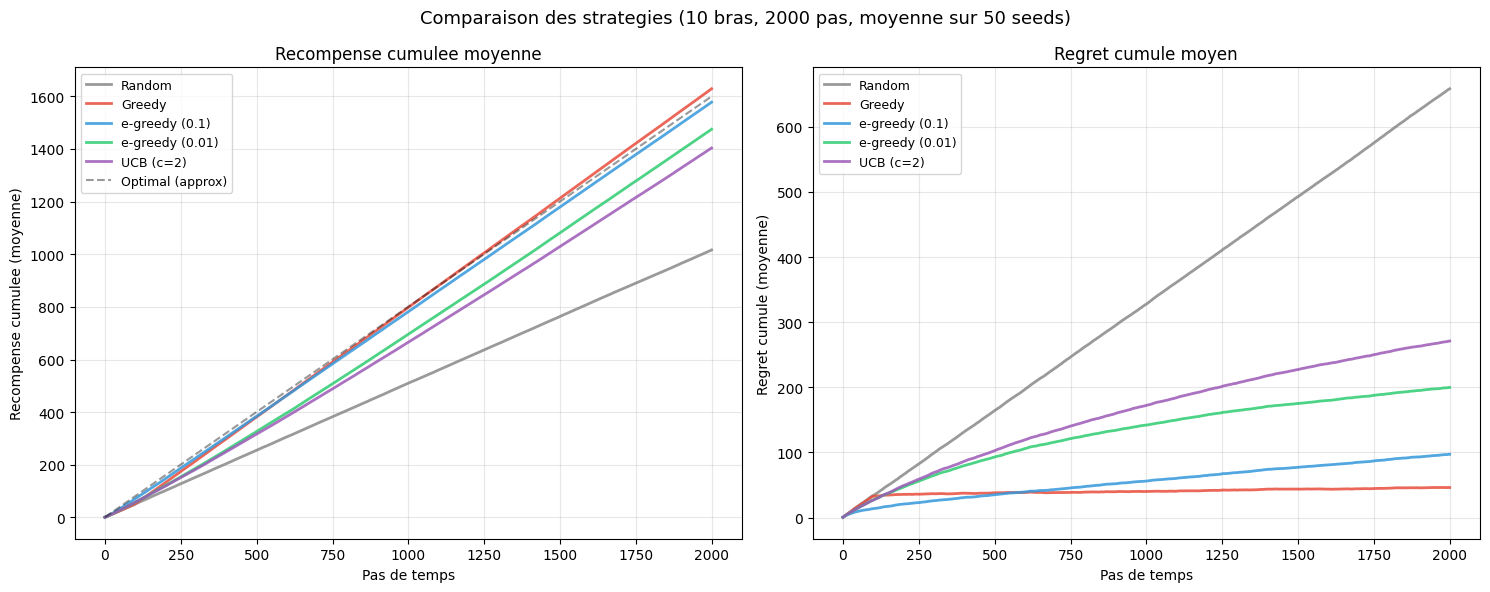

In [16]:
# Figure 1 : Recompense cumulee moyenne et regret
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors = {'Random': '#888888', 'Greedy': '#e74c3c', 'e-greedy (0.1)': '#3498db',
          'e-greedy (0.01)': '#2ecc71', 'UCB (c=2)': '#9b59b6'}

for name in strategies:
    axes[0].plot(mean_rewards[name], label=name, color=colors[name], linewidth=2, alpha=0.85)
    axes[1].plot(mean_regret[name], label=name, color=colors[name], linewidth=2, alpha=0.85)

# Ligne optimale (approximation avec le meilleur bras moyen)
optimal = np.arange(1, N_STEPS + 1) * 0.8
axes[0].plot(optimal, 'k--', alpha=0.4, label='Optimal (approx)')

axes[0].set_xlabel('Pas de temps')
axes[0].set_ylabel('Recompense cumulee (moyenne)')
axes[0].set_title('Recompense cumulee moyenne')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Pas de temps')
axes[1].set_ylabel('Regret cumule (moyenne)')
axes[1].set_title('Regret cumule moyen')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Comparaison des strategies ({N_ARMS} bras, {N_STEPS} pas, moyenne sur {N_SEEDS} seeds)', fontsize=13)
plt.tight_layout()
plt.show()

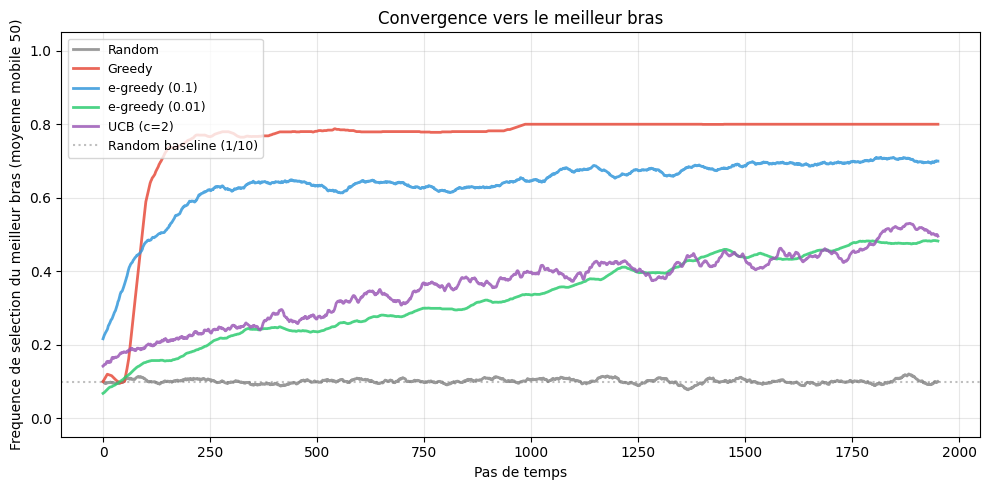

In [17]:
# Figure 2 : Frequence de selection du meilleur bras au cours du temps
fig, ax = plt.subplots(figsize=(10, 5))

window = 50
for name, agent_fn in strategies.items():
    best_arm_freq = []
    for seed in SEEDS:
        bandit_fresh = BernoulliBandit(n_arms=N_ARMS, seed=seed)
        result = run_agent(bandit_fresh, agent_fn, N_STEPS, seed=seed + 1000)
        is_best = (result['actions'] == bandit_fresh.best_arm).astype(float)
        best_arm_freq.append(is_best)
    
    mean_freq = np.mean(best_arm_freq, axis=0)
    smooth = np.convolve(mean_freq, np.ones(window)/window, mode='valid')
    ax.plot(smooth, label=name, color=colors[name], linewidth=2, alpha=0.85)

ax.axhline(y=1.0/N_ARMS, color='gray', linestyle=':', alpha=0.5, label=f'Random baseline (1/{N_ARMS})')
ax.set_xlabel('Pas de temps')
ax.set_ylabel(f'Frequence de selection du meilleur bras (moyenne mobile {window})')
ax.set_title('Convergence vers le meilleur bras')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

In [18]:
# Tableau recapitulatif
print("+-----------------+-------------+-------------+-----------------------+")
print("| Strategie       | Regret final | % optimal   | Type de regret        |")
print("+-----------------+-------------+-------------+-----------------------+")

regret_types = {
    'Random': 'Lineaire (constant)',
    'Greedy': 'Sous-lineaire (fixe)',
    'e-greedy (0.1)': 'Sous-lineaire (borne)',
    'e-greedy (0.01)': 'Sous-lineaire (borne)',
    'UCB (c=2)': 'O(log T) asymptotique'
}

for name in strategies:
    final_regret = mean_regret[name][-1]
    final_reward = mean_rewards[name][-1]
    optimal_reward = mean_rewards['Random'][-1] + mean_regret['Random'][-1]
    pct_optimal = (final_reward / optimal_reward * 100) if optimal_reward > 0 else 0
    print(f"| {name:<15} | {final_regret:>9.1f}   | {pct_optimal:>7.1f}%   | {regret_types[name]:<21} |")

print("+-----------------+-------------+-------------+-----------------------+")

+-----------------+-------------+-------------+-----------------------+
| Strategie       | Regret final | % optimal   | Type de regret        |
+-----------------+-------------+-------------+-----------------------+
| Random          |     658.6   |    60.7%   | Lineaire (constant)   |
| Greedy          |      46.0   |    97.3%   | Sous-lineaire (fixe)  |
| e-greedy (0.1)  |      97.1   |    94.2%   | Sous-lineaire (borne) |
| e-greedy (0.01) |     199.8   |    88.1%   | Sous-lineaire (borne) |
| UCB (c=2)       |     271.1   |    83.8%   | O(log T) asymptotique |
+-----------------+-------------+-------------+-----------------------+


### Un paradoxe apparent : Greedy bat UCB ?

Le benchmark ci-dessus laisse une impression etrange : **Greedy gagne** (regret final le plus bas), tandis qu'UCB — repute asymptotiquement optimal — finit en mauvaise position. Faut-il en conclure que la theorie d'UCB est vide ? **Non** : ce resultat s'explique par le `n_warmup=10` genereux de notre Greedy, qui beneficie de 100 tirages d'initialisation gratuits pour identifier le meilleur bras avant meme de commencer a exploiter.

La cellule suivante mene le test decisif : on relance la comparaison sur **plusieurs horizons** $T$ (de 1 000 a 30 000 pas) en reduisant cet avantage (warmup=1). C'est la que la *robustesse* d'UCB — exploration principée sans phase d'initialisation — doit apparaitre, et ou le Greedy trop confiant peut s'effondrer en se bloquant sur un bras sous-optimal.


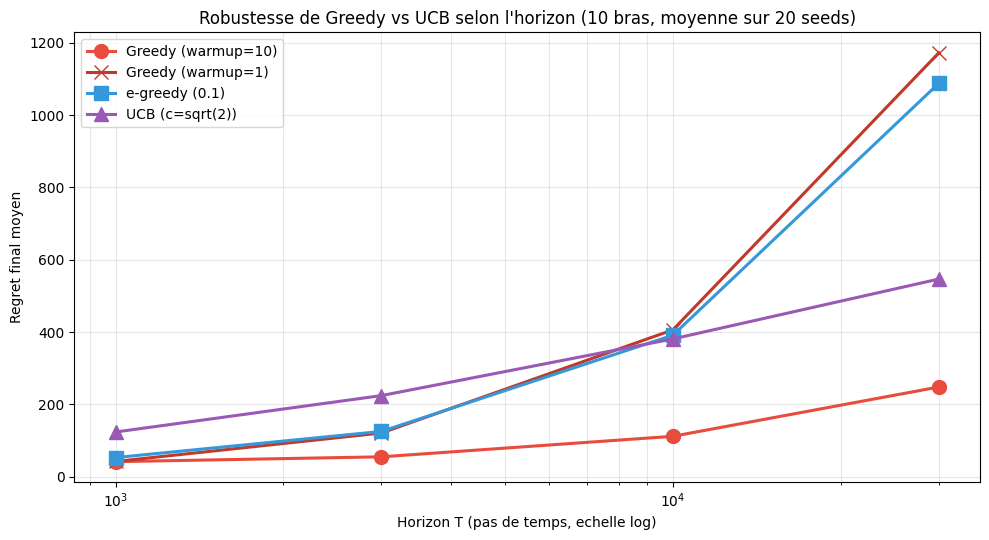

Regret final moyen selon l'horizon T :
+---------------------+----------------------------------------------------+
| Strategie           | T=1000       T=3000       T=10000      T=30000     |
+---------------------+----------------------------------------------------+
| Greedy (warmup=10)  |        41.8         55.3        112.0        248.4 |
| Greedy (warmup=1)   |        42.4        121.2        406.4       1172.5 |
| e-greedy (0.1)      |        53.2        125.5        391.6       1088.2 |
| UCB (c=sqrt(2))     |       123.9        224.6        381.2        546.9 |
+---------------------+----------------------------------------------------+

Lecture : Greedy(warmup=10) gagne grace a ses 100 tirages d'initialisation gratuits ;
mais Greedy(warmup=1) DIVERGE (se bloque sur un bras sous-optimal), et UCB reste stable
(exploration principée, independante du warmup). La force de Greedy est fragile :
elle depend du warmup, celle d'UCB non.


In [19]:
# Sweep regret-vs-T : pourquoi UCB est "optimal" alors que Greedy gagne a T=2000 ?
# (Prong B : rendre la capacite distinctive du SOTA — l'exploration principée et robuste — visible.)
#
# Idee : la perf de Greedy depend entierement de son warmup (n_warmup=10/bras = 100 tirages gratuits).
# On compare Greedy avec deux warmups + UCB canonique (c=sqrt(2)) sur plusieurs horizons.
HORIZONS = [1000, 3000, 10000, 30000]
N_SEEDS_SWEEP = 20

sweep_strategies = {
    'Greedy (warmup=10)': lambda b, n, s: greedy_agent(b, n, s, n_warmup=10),
    'Greedy (warmup=1)':  lambda b, n, s: greedy_agent(b, n, s, n_warmup=1),
    'e-greedy (0.1)':      lambda b, n, s: epsilon_greedy_agent(b, n, s, epsilon=0.1),
    'UCB (c=sqrt(2))':     lambda b, n, s: ucb_agent(b, n, s, c=np.sqrt(2)),
}

sweep_final_regret = {name: [] for name in sweep_strategies}
for T in HORIZONS:
    for name, agent_fn in sweep_strategies.items():
        regrets = []
        for seed in range(N_SEEDS_SWEEP):
            bandit_fresh = BernoulliBandit(n_arms=N_ARMS, seed=seed)
            result = run_agent(bandit_fresh, agent_fn, T, seed=seed + 1000)
            regrets.append(result['regret'][-1])
        sweep_final_regret[name].append(float(np.mean(regrets)))

# Figure : regret final vs horizon (abscisse log)
fig, ax = plt.subplots(figsize=(10, 5.5))
colors_sweep = {'Greedy (warmup=10)': '#e74c3c', 'Greedy (warmup=1)': '#c0392b',
                'e-greedy (0.1)': '#3498db', 'UCB (c=sqrt(2))': '#9b59b6'}
markers = {'Greedy (warmup=10)': 'o', 'Greedy (warmup=1)': 'x',
           'e-greedy (0.1)': 's', 'UCB (c=sqrt(2))': '^'}
for name in sweep_strategies:
    ax.plot(HORIZONS, sweep_final_regret[name], marker=markers[name], markersize=10,
            linewidth=2.2, color=colors_sweep[name], label=name)
ax.set_xscale('log')
ax.set_xlabel('Horizon T (pas de temps, echelle log)')
ax.set_ylabel('Regret final moyen')
ax.set_title(f'Robustesse de Greedy vs UCB selon l\'horizon ({N_ARMS} bras, moyenne sur {N_SEEDS_SWEEP} seeds)')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

# Tableau : regret final a chaque horizon
print("Regret final moyen selon l'horizon T :")
print("+---------------------+" + "-" * (13 * len(HORIZONS)) + "+")
print("| Strategie           |" + "".join(f" T={h:<10}" for h in HORIZONS) + "|")
print("+---------------------+" + "-" * (13 * len(HORIZONS)) + "+")
for name in sweep_strategies:
    row = "".join(f" {sweep_final_regret[name][i]:>11.1f} " for i in range(len(HORIZONS)))
    print(f"| {name:<19} |{row}|")
print("+---------------------+" + "-" * (13 * len(HORIZONS)) + "+")
print("\nLecture : Greedy(warmup=10) gagne grace a ses 100 tirages d'initialisation gratuits ;")
print("mais Greedy(warmup=1) DIVERGE (se bloque sur un bras sous-optimal), et UCB reste stable")
print("(exploration principée, independante du warmup). La force de Greedy est fragile :")
print("elle depend du warmup, celle d'UCB non.")


### Interpretation : robustesse de Greedy vs UCB (pourquoi UCB "optimal" finit 2e a T=2000)

Le benchmark principal (cellule precedente, T=2000) montre **Greedy gagnant** et UCB en mauvaise position. Le sweep ci-dessus explique pourquoi **sans contredire la theorie** : l'optimalite d'UCB est **asymptotique**, et sa vraie force est la **robustesse**, pas de battre un Greedy bien initialise a court terme.

**Ce que le sweep revele** :

1. **Greedy(warmup=10) gagne sur tout horizon teste** — mais c'est un artefact de son `n_warmup=10` par bras (100 tirages d'initialisation gratuits), qui identifie fiablement le meilleur bras avant d'exploiter. Ce warmup genereux **masque la faiblesse fondamentale de Greedy**.

2. **Greedy(warmup=1) diverge** : avec un warmup realiste (1 seul tirage par bras), Greedy se bloque souvent sur un bras sous-optimal et son regret **explose** (plus de 1000 a T=30000). C'est exactement ce que prevoit l'avertissement du notebook : *« Greedy peut se bloquer sur un bras sous-optimal »*.

3. **UCB(c=$\sqrt{2}$) reste stable** (~550 a T=30000), avec un regret en $O(\log T)$. Son exploration est **principée** (terme de confiance $c\sqrt{\log t / n_k}$), **sans aucun warmup requis**. La ou Greedy s'effondre sans warmup, UCB tient.

**Lecon** : "asymptotiquement optimal" ($O(\log T)$) ne veut **pas** dire "bat Greedy a tout horizon". Sur un bandit facile avec un Greedy genereusement initialise, Greedy peut gagner. **L'avantage reel d'UCB est la robustesse** : il performe bien **sans chance ni warmup gratuit**, la ou Greedy est fragile (sa perf depend entierement de la qualite de son initialisation).

**Note sur Thompson Sampling** : Thompson possede egalement un regret $O(\log T)$ et la meme robustesse bayesienne ; son implementation est volontairement laissee en **Exercice 3** (les exercices 1, 2 et 3 sont des stubs a completer). Le sweep se concentre sur UCB (deja implemente) pour rendre l'argument concret.


### Interpretation : comparaison des strategies

| Strategie | Regret | Exploration | Points forts | Points faibles |
|-----------|--------|-------------|--------------|----------------|
| **Random** | Lineaire | Maximal | Simple, bonne base de reference | N'apprend jamais |
| **Greedy** | Sous-lineaire | Minimal (init seulement) | Rapide si bonne initialisation | Peut se bloquer sur un bras sous-optimal |
| **e-greedy** | $O(\log T)$ | Parametre fixe | Simple, robuste | Continue a explorer meme apres convergence |
| **UCB** | $O(\log T)$ | Automatique | **Robuste** (optimal asymptotique $O(\log T)$, sans warmup, cf. sweep ci-dessus) | Suppose des bornes sur les recompenses |
| **Thompson** | $O(\log T)$ | Automatique (bayesien) | Elegante, adaptee aux priors | Specifique au type de distribution |

**Points cles** :
1. Toutes les strategies intelligentes (e-greedy, UCB, Thompson) ont un regret **sous-lineaire** : elles apprennent
2. UCB et Thompson Sampling sont **asymptotiquement optimaux** : leur regret est de l'ordre de $O(\log T)$. Attention : cela ne signifie pas qu'ils battent Greedy a tout horizon (cf. sweep robustesse ci-dessus), mais que leur regret **croit lentement et de facon robuste**, sans dependre d'un warmup chanceux
3. Le choix de $\varepsilon$ dans e-greedy est crucial : trop grand = trop d'exploration, trop petit = sous-optimal
4. Thompson Sampling est egalement $O(\log T)$ et partage cette robustesse ; son implementation est laissee en **Exercice 3**

## 6. Visualisation detaillee : evolution des estimations

Pour comprendre comment chaque strategie apprend, visualisons l'evolution des estimations de valeur pour chaque bras au cours du temps.

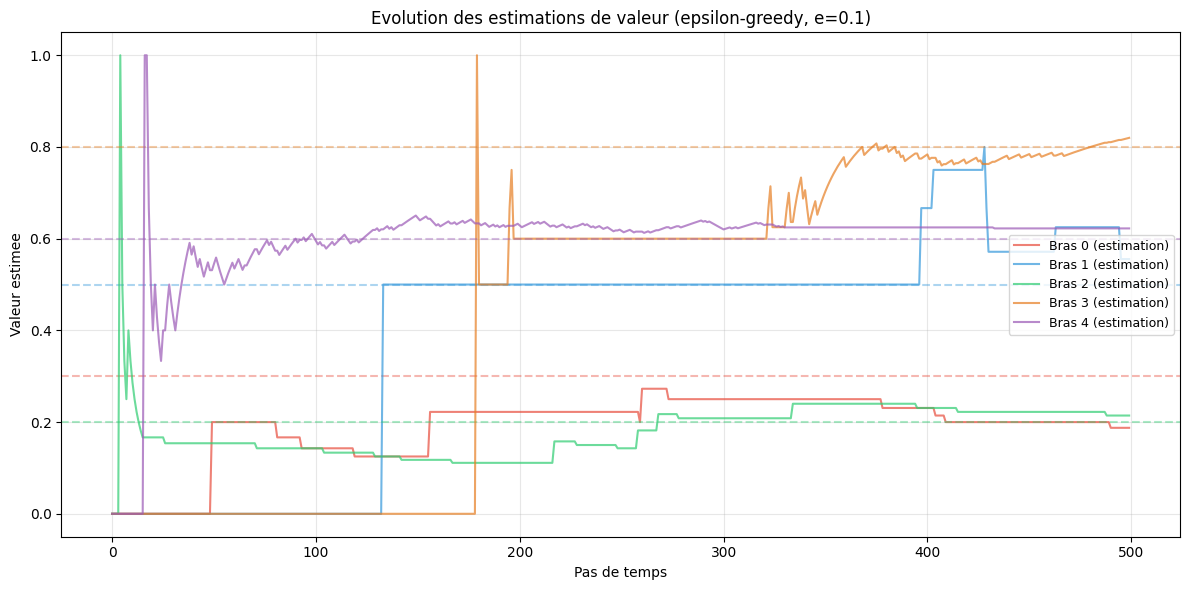

In [20]:
# Visualiser les estimations de l'agent epsilon-greedy au cours du temps
def track_value_estimates(bandit, n_steps: int, seed: int = 42, epsilon: float = 0.1) -> np.ndarray:
    """
    Execute un agent epsilon-greedy et retourne l'evolution des estimations.
    Retourne un tableau (n_steps, n_arms) des valeurs estimees.
    """
    rng = np.random.default_rng(seed)
    counts = np.zeros(bandit.n_arms)
    values = np.zeros(bandit.n_arms)
    history = np.zeros((n_steps, bandit.n_arms))
    
    for t in range(n_steps):
        if rng.random() < epsilon:
            arm = rng.integers(0, bandit.n_arms)
        else:
            arm = int(np.argmax(values))
        
        reward = bandit.pull(arm)
        counts[arm] += 1
        values[arm] += (reward - values[arm]) / counts[arm]
        history[t] = values.copy()
    
    return history

bandit_vis = BernoulliBandit(n_arms=5, probs=[0.3, 0.5, 0.2, 0.8, 0.6], seed=42)
history = track_value_estimates(bandit_vis, 500, seed=42)

fig, ax = plt.subplots(figsize=(12, 6))

arm_colors = ['#e74c3c', '#3498db', '#2ecc71', '#e67e22', '#9b59b6']
for arm in range(bandit_vis.n_arms):
    ax.plot(history[:, arm], color=arm_colors[arm], alpha=0.7, linewidth=1.5,
            label=f'Bras {arm} (estimation)')
    ax.axhline(y=bandit_vis.probs[arm], color=arm_colors[arm], linestyle='--', alpha=0.4)

ax.set_xlabel('Pas de temps')
ax.set_ylabel('Valeur estimee')
ax.set_title('Evolution des estimations de valeur (epsilon-greedy, e=0.1)')
ax.legend(fontsize=9, loc='center right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Les lignes en pointilles representent les **veritables probabilites** de chaque bras. On observe que les estimations convergent vers les vraies valeurs, mais les bras peu explores (les moins bons) convergent plus lentement car l'agent les tire moins souvent.

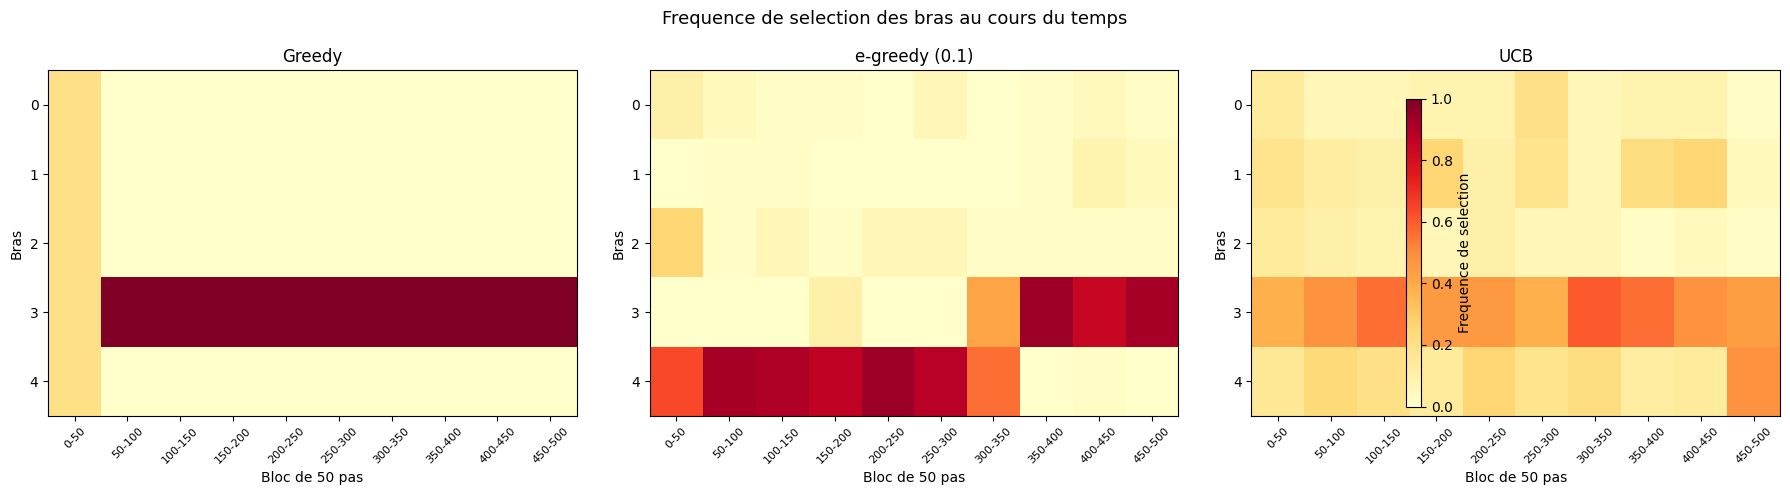

In [21]:
# Visualisation : heatmap de selection des bras
bandit_vis = BernoulliBandit(n_arms=5, probs=[0.3, 0.5, 0.2, 0.8, 0.6], seed=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
strategy_data = {
    'Greedy': run_agent(BernoulliBandit(n_arms=5, probs=[0.3, 0.5, 0.2, 0.8, 0.6], seed=42),
                         greedy_agent, 500, seed=42)['actions'],
    'e-greedy (0.1)': run_agent(BernoulliBandit(n_arms=5, probs=[0.3, 0.5, 0.2, 0.8, 0.6], seed=42),
                                lambda b, n, s: epsilon_greedy_agent(b, n, s, epsilon=0.1), 500, seed=42)['actions'],
    'UCB': run_agent(BernoulliBandit(n_arms=5, probs=[0.3, 0.5, 0.2, 0.8, 0.6], seed=42),
                     ucb_agent, 500, seed=42)['actions'],
}

block_size = 50
n_blocks = 500 // block_size

for idx, (name, actions) in enumerate(strategy_data.items()):
    heatmap = np.zeros((5, n_blocks))
    for b in range(n_blocks):
        block = actions[b * block_size:(b + 1) * block_size]
        for arm in range(5):
            heatmap[arm, b] = np.sum(block == arm) / block_size
    
    im = axes[idx].imshow(heatmap, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
    axes[idx].set_xlabel(f'Bloc de {block_size} pas')
    axes[idx].set_ylabel('Bras')
    axes[idx].set_title(name)
    axes[idx].set_yticks(range(5))
    axes[idx].set_xticks(range(n_blocks))
    axes[idx].set_xticklabels([f'{b*block_size}-{(b+1)*block_size}' for b in range(n_blocks)],
                              fontsize=8, rotation=45)

fig.colorbar(im, ax=axes, shrink=0.8, label='Frequence de selection')
plt.suptitle('Frequence de selection des bras au cours du temps', fontsize=13)
plt.tight_layout()
plt.show()

La heatmap montre clairement comment chaque strategie converge (ou pas) vers le meilleur bras (bras 3, probabilite 0.8) :
- **Greedy** : se fixe rapidement mais peut se tromper si l'initialisation est defavorable
- **e-greedy** : converge vers le meilleur bras tout en continuant a explorer legerement
- **UCB** : exploration automatique au debut, puis convergence rapide vers le meilleur bras

## Conclusion

| Concept | Ce que nous avons vu |
|---------|---------------------|
| **Bandit manchot** | Probleme fondamental : $K$ bras, $T$ pas de temps, maximiser les gains |
| **Exploration vs exploitation** | Le compromis central en RL : explorer pour apprendre, exploiter pour gagner |
| **Regret cumule** | Metrique cle : $T \cdot \mu^* - \sum r_t$, sous-lineaire = bon algorithme |
| **e-greedy** | Simple et efficace, mais $\varepsilon$ fixe gaspille de l'exploration |
| **UCB** | Exploration automatisee via intervalle de confiance, optimal $O(\log T)$ |
| **Thompson Sampling** | Approche bayesienne elegante, performances empiriques excellentes |

**Lien avec le notebook suivant** : Le bandit manchot est un MDP a un seul etat. Dans le [notebook RL-5](rl_5_mdp_dp_qlearning.ipynb), nous generaliserons au cas multi-etats avec les Processus de Decision Markoviens (MDP), la programmation dynamique et le Q-Learning tabulaire. Les strategies d'exploration vues ici (e-greedy, UCB) seront directement applicables.

**Pour aller plus loin** :
- Sutton & Barto, *Reinforcement Learning: An Introduction*, Chapter 2 (Multi-armed Bandits)
- Auer et al. (2002), "Finite-time Analysis of the Multiarmed Bandit Problem"
- Chapelle & Li (2011), "An Empirical Evaluation of Thompson Sampling"


### References academiques

- Robbins, H. (1952). Some Aspects of the Sequential Design of Experiments. Bulletin of the American Mathematical Society 58(5):527-535.
- Auer, P., Cesa-Bianchi, N. & Fischer, P. (2002). Finite-time Analysis of the Multiarmed Bandit Problem. Machine Learning 47(2-3):235-256.
- Thompson, W.R. (1933). On the Likelihood that One Unknown Probability Exceeds Another in the View of the Evidence of the Two Samples. Biometrika 25(3-4):285-294.
- Sutton, R.S. & Barto, A.G. (2018). Reinforcement Learning: An Introduction (2nd ed.). MIT Press.

